# No Flux Boundary Experiments

## Setup

### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os


### Import helper functions 

In [2]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Initialization

In [3]:

#defind varaibles

#10 mil
n_parts = 10000000

T = 4
dt = 0.01

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions

b = lambda x: constant_drift(x, value=1)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1)


### Initial distribution

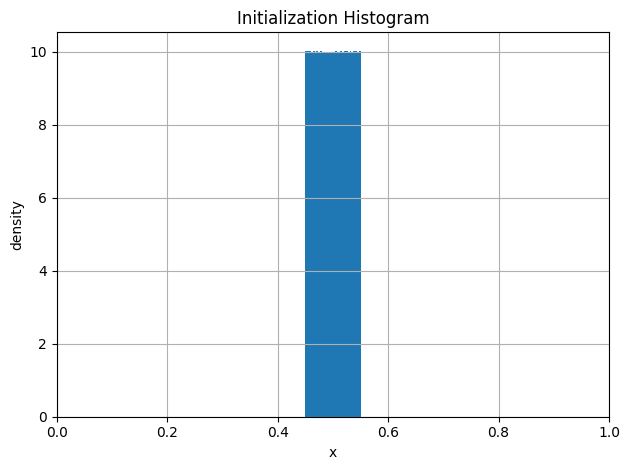

In [4]:
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plot_histogram(X_0, 30, title="Initialization Histogram", x_limit=x_bounds)

plt.tight_layout()
plt.show()

## Initial Experiments

### Compore general solutions with reflection, rejection, theta ($\theta =0.5$) and half-step boundary conditions

In [5]:


X_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=x_bounds)

X_rej  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=x_bounds)

X_theta  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5), boundaries=x_bounds)

X_half  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="half_step", boundaries=x_bounds)


### Plot the numerical and exact solutions

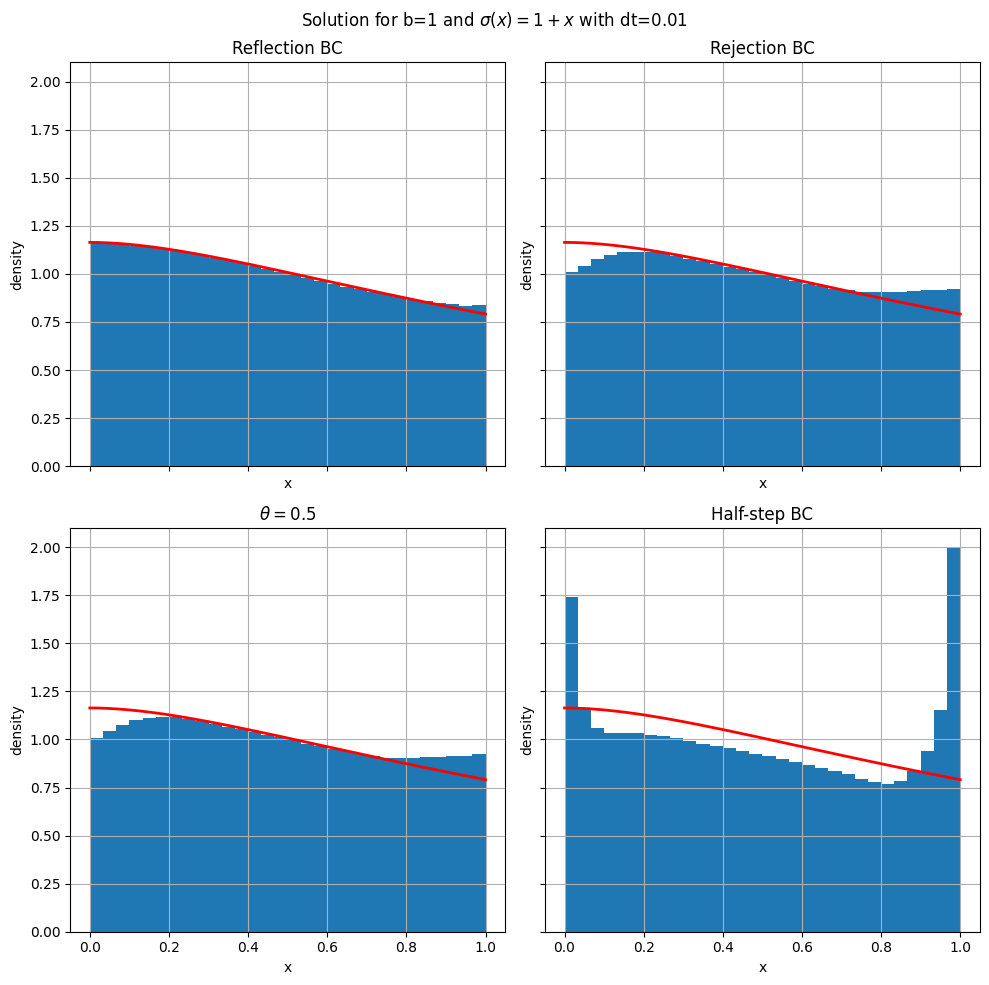

In [6]:
#compute the true solution
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

# plot full histogram
fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharey=True, sharex=True)
ax = ax.flatten()

fig.suptitle(fr"Solution for b={b(1)} and $\sigma(x)=1+x$ with {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[2], title=r'$\theta=0.5$', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_half, bins=30, ax=ax[3], title=r'Half-step BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[3].plot(x_plot, p_exact, "r", linewidth=2)


plt.tight_layout()
plt.show()



## Cases analysis

for each case we are doing the following:
- define case and parameters
- general full domain solution numerical vs exact
- solution near the boundaries
- full domain local error plot
- Convergence plot per BC

- Boundary local error plot
- Scaled boundary-layer plot across dt


## Analysis for case $b=0$ and $\sigma = 1$

### Parameters

In [3]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=0)
sigma = lambda x: constant_diffusion(x, value=1) 

#these are used to load generated solutions
problem_path = "./data/b-0_s-1"
boundary_types = ["reflection", "rejection", "theta-0.5", "half-step"]
dt_list = [0.16, 0.04, 0.01, 0.0025]

### General solution

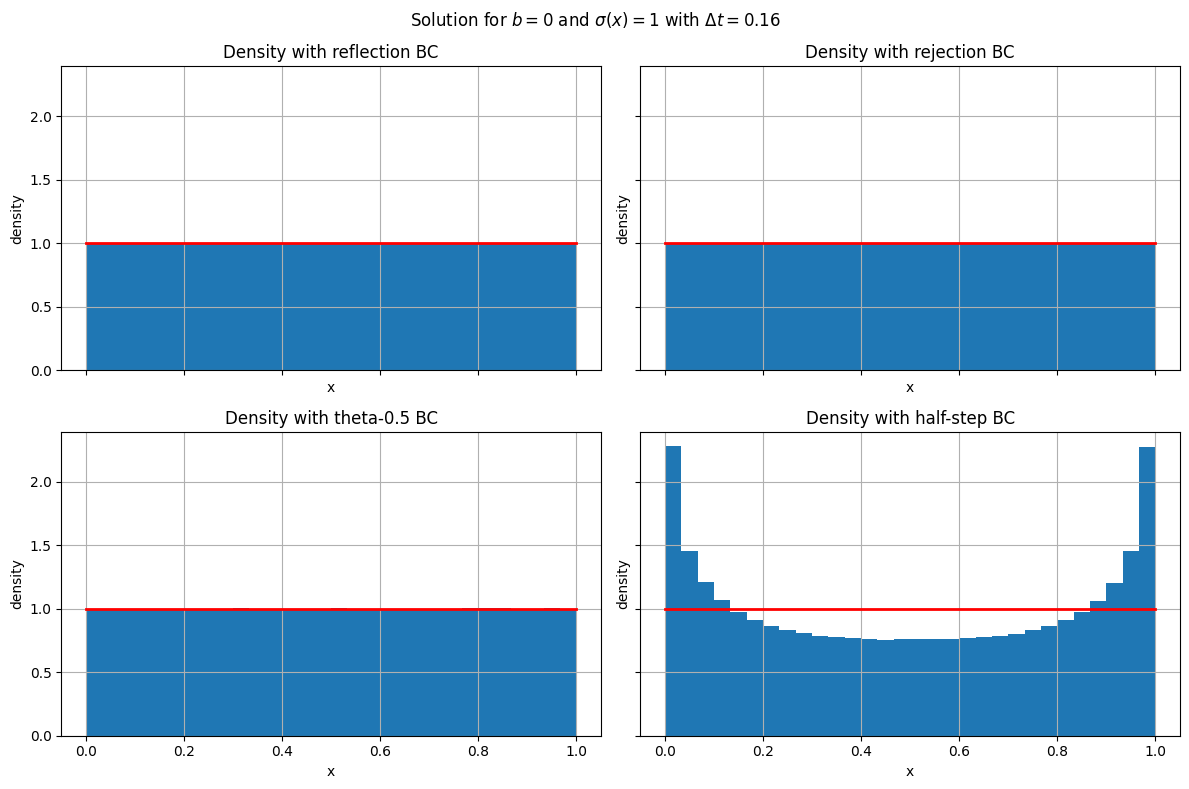

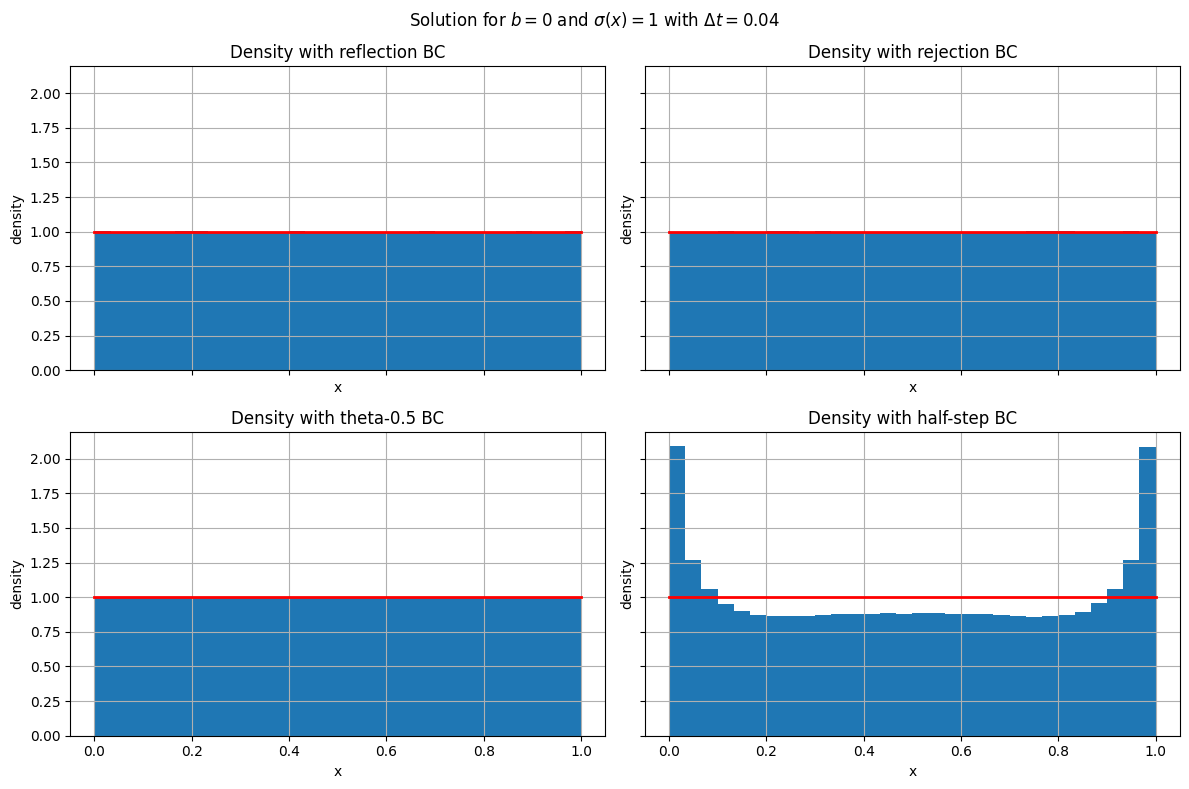

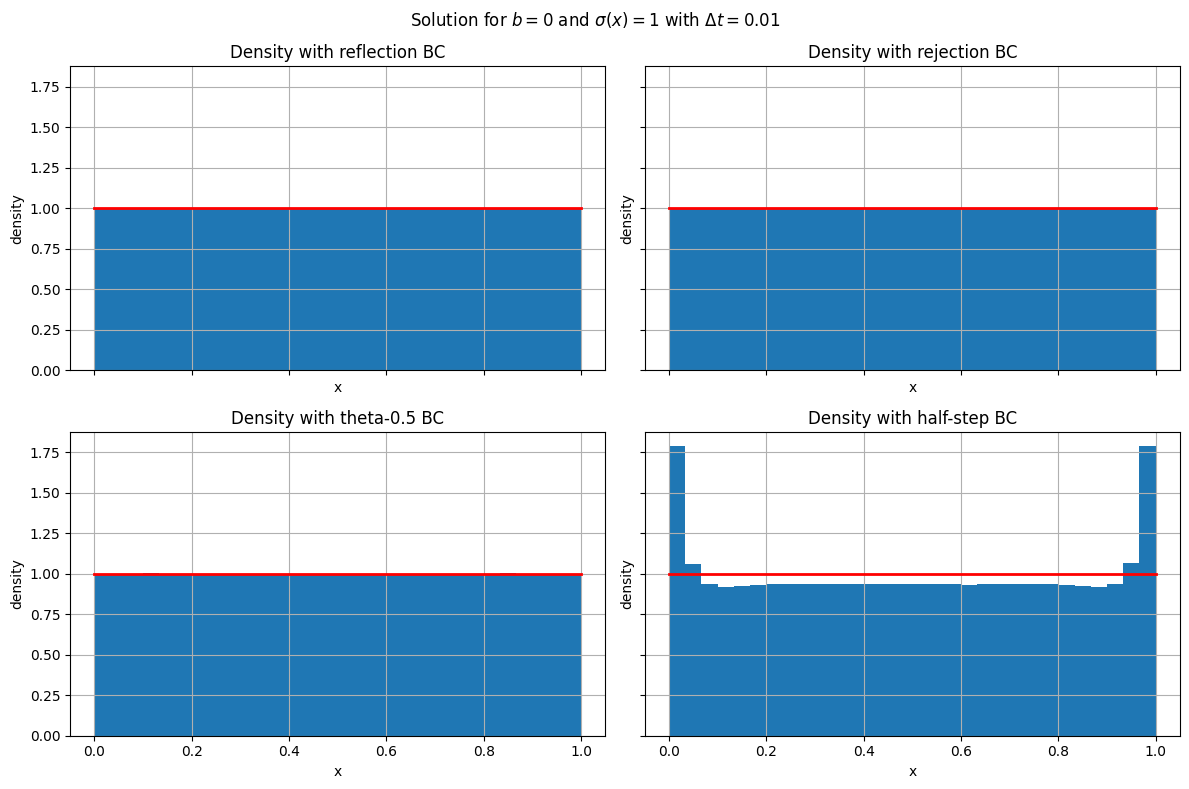

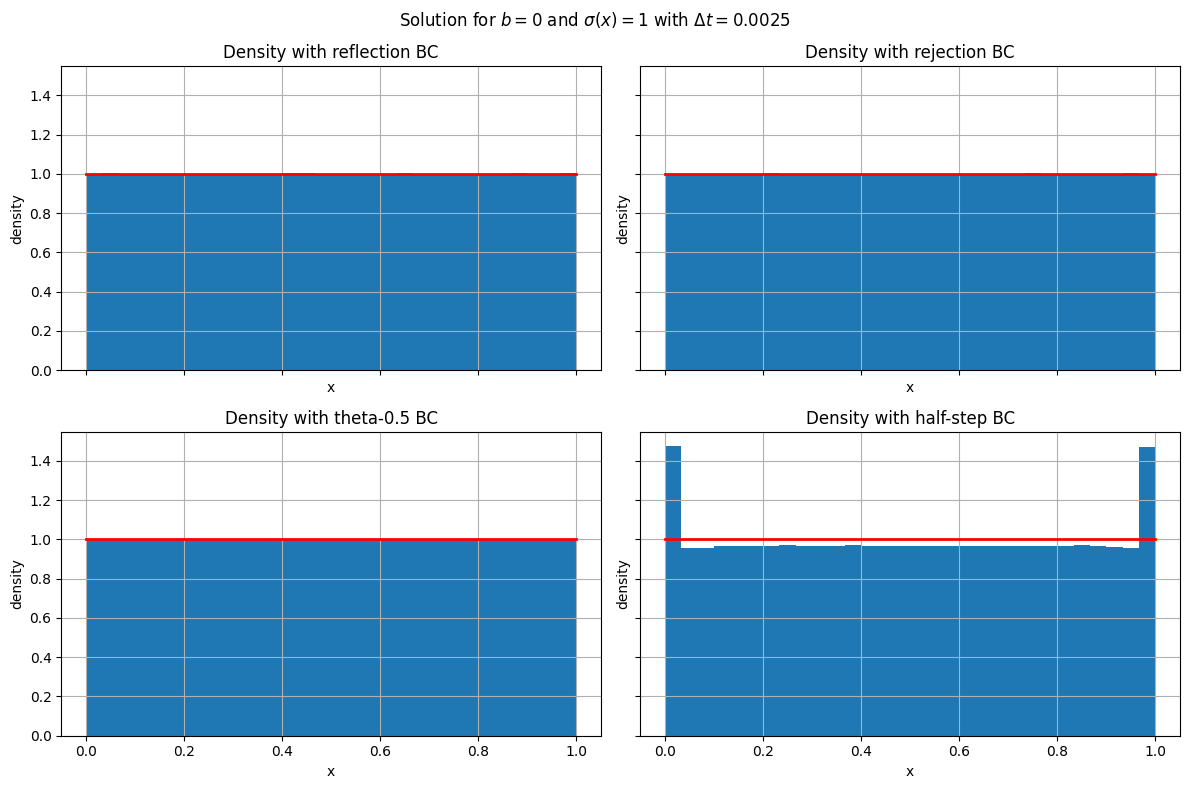

In [4]:

#compute the stationary solution
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)


for dt in dt_list:

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
    ax = ax.flatten()

    fig.suptitle(fr"Solution for $b=0$ and $\sigma(x)=1$ with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_histogram(X=X, bins=30, ax=ax[i], title=f'Density with {boundary_type} BC'
                       ,x_label='x', y_label='density', density=True, x_limit=None)
        ax[i].plot(x_plot, p_exact, "r", linewidth=2)

    plt.tight_layout()
    plt.show()


### Solutions in the range $[0,\varepsilon]$

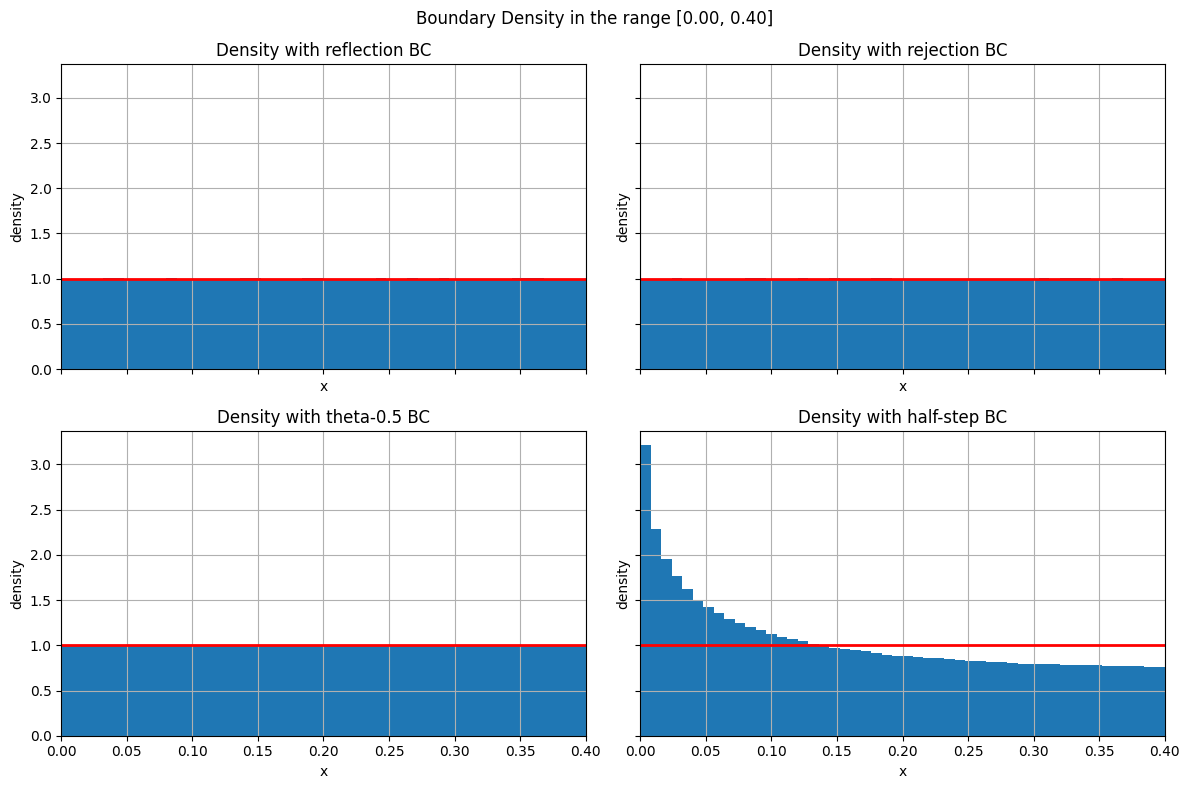

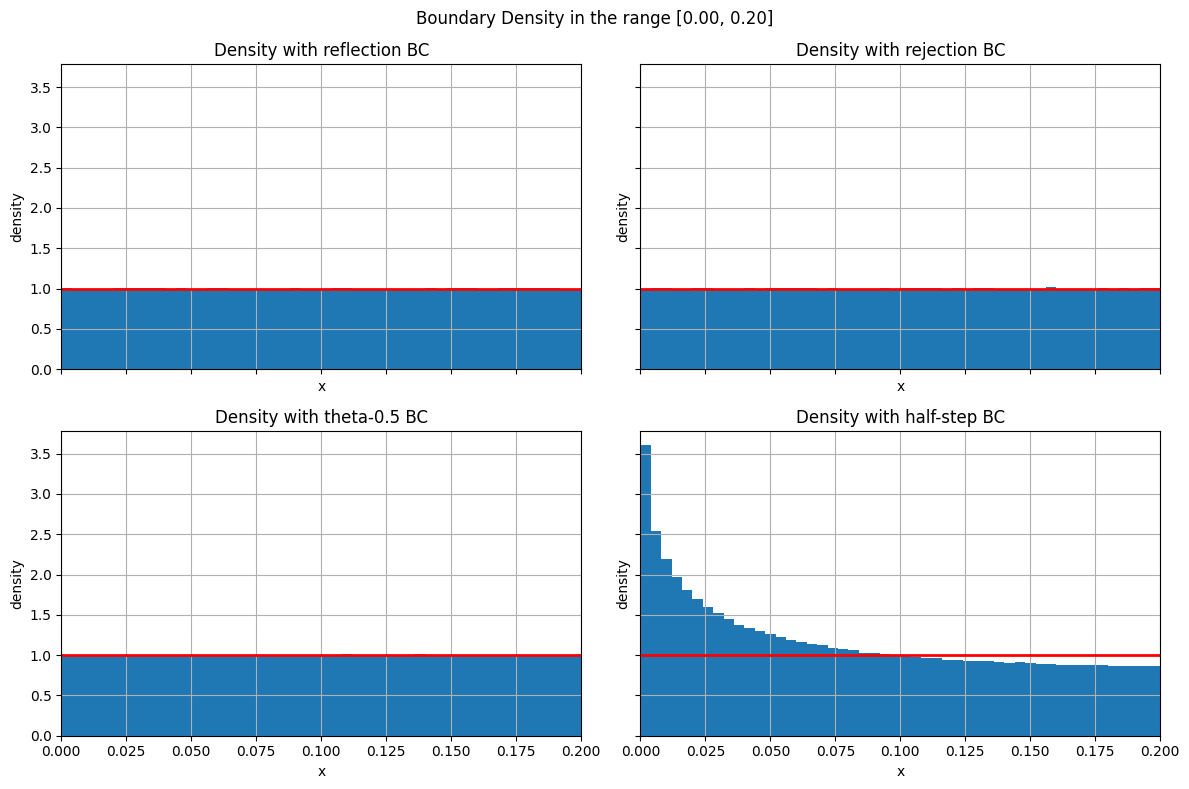

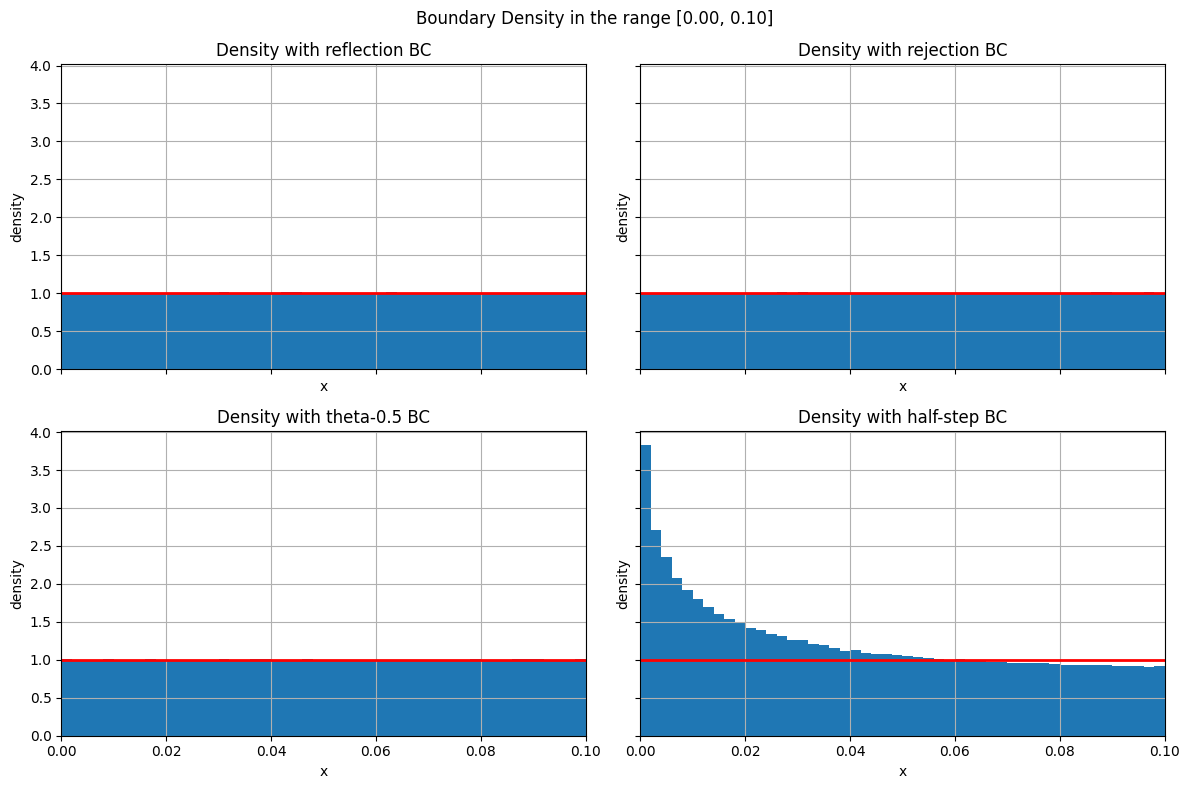

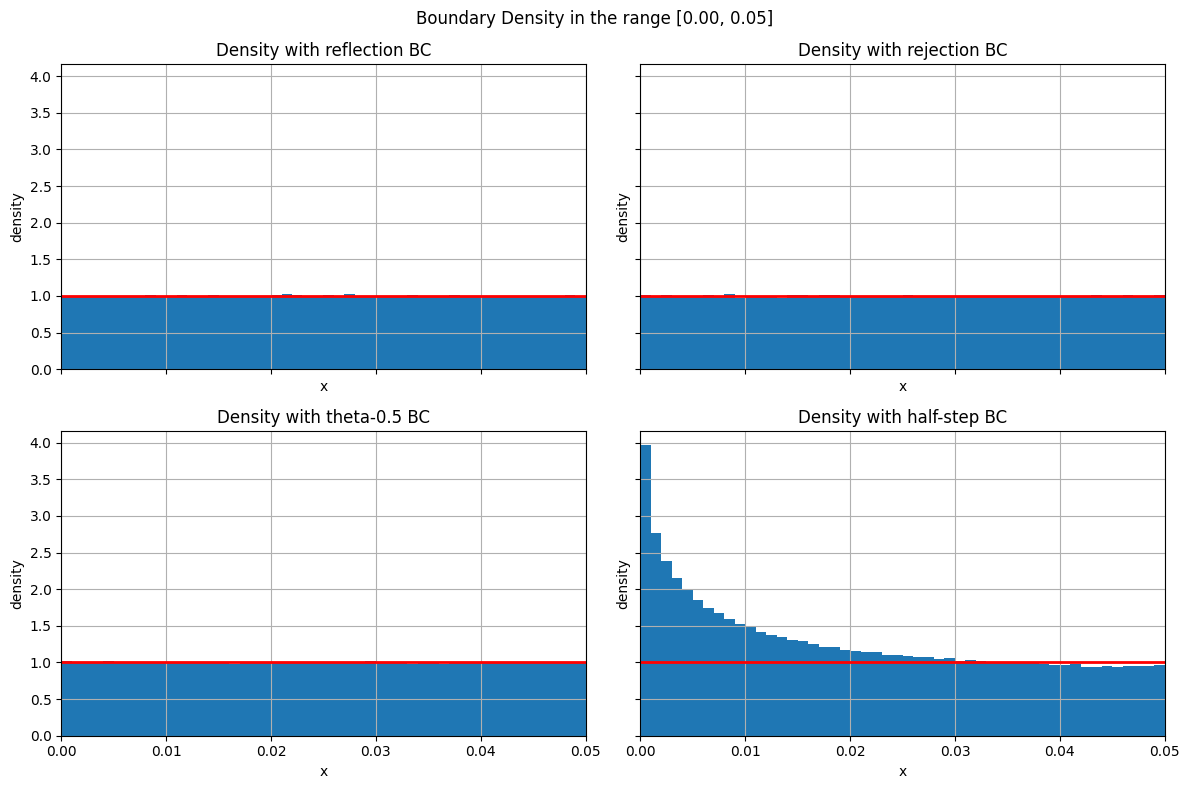

In [ ]:

bins=50

for dt in dt_list:

    epsilon = np.sqrt(dt)
    x_range = (x_bounds[0], x_bounds[0] + epsilon)

    x_plot = np.linspace(x_range[0], x_range[1], 500)
    p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    ax = ax.flatten()

    fig.suptitle(fr"Boundary Density in the range [{x_range[0]:.2f}, {x_range[1]:.2f}] with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_local_density(X=X, x_range=x_range, bins=bins, ax=ax[i]
                           , title=f'Density with {boundary_type} BC')
        ax[i].plot(x_plot, p_exact , "r", linewidth=2)

    plt.tight_layout()
    plt.show()



### Solutions in the range $[1-\varepsilon, 1]$

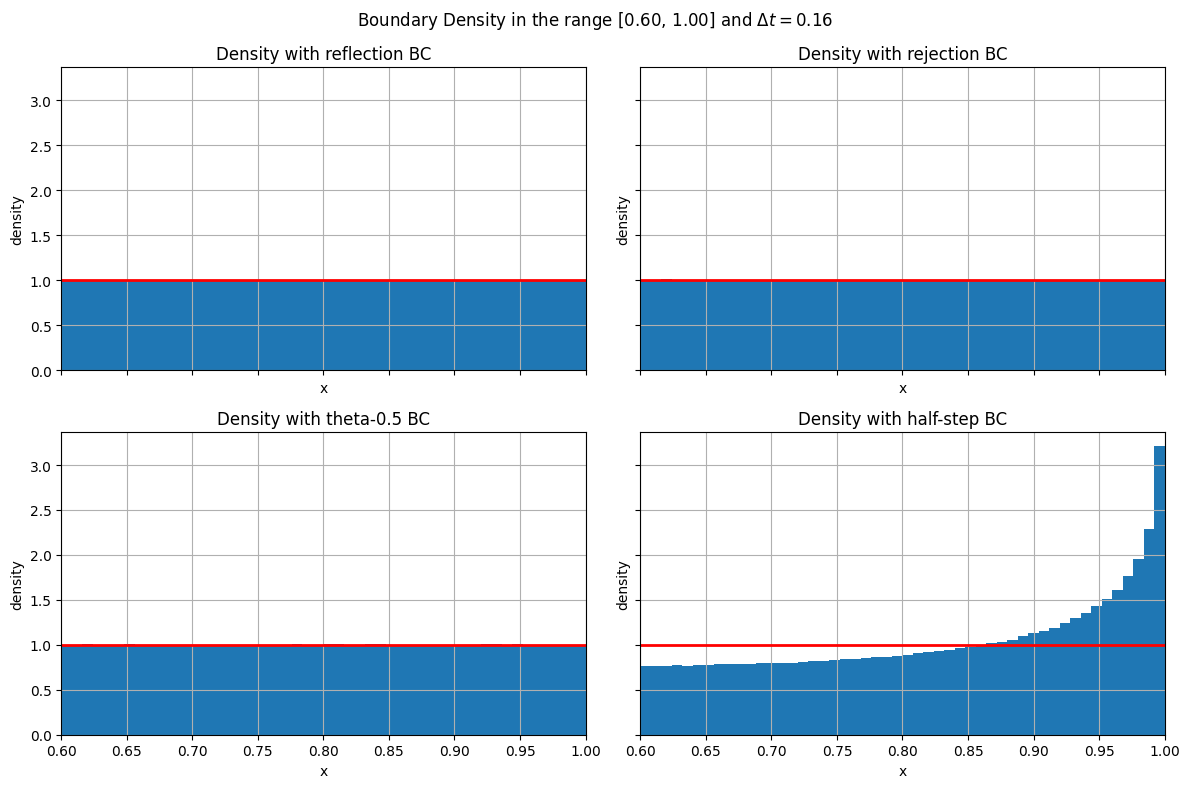

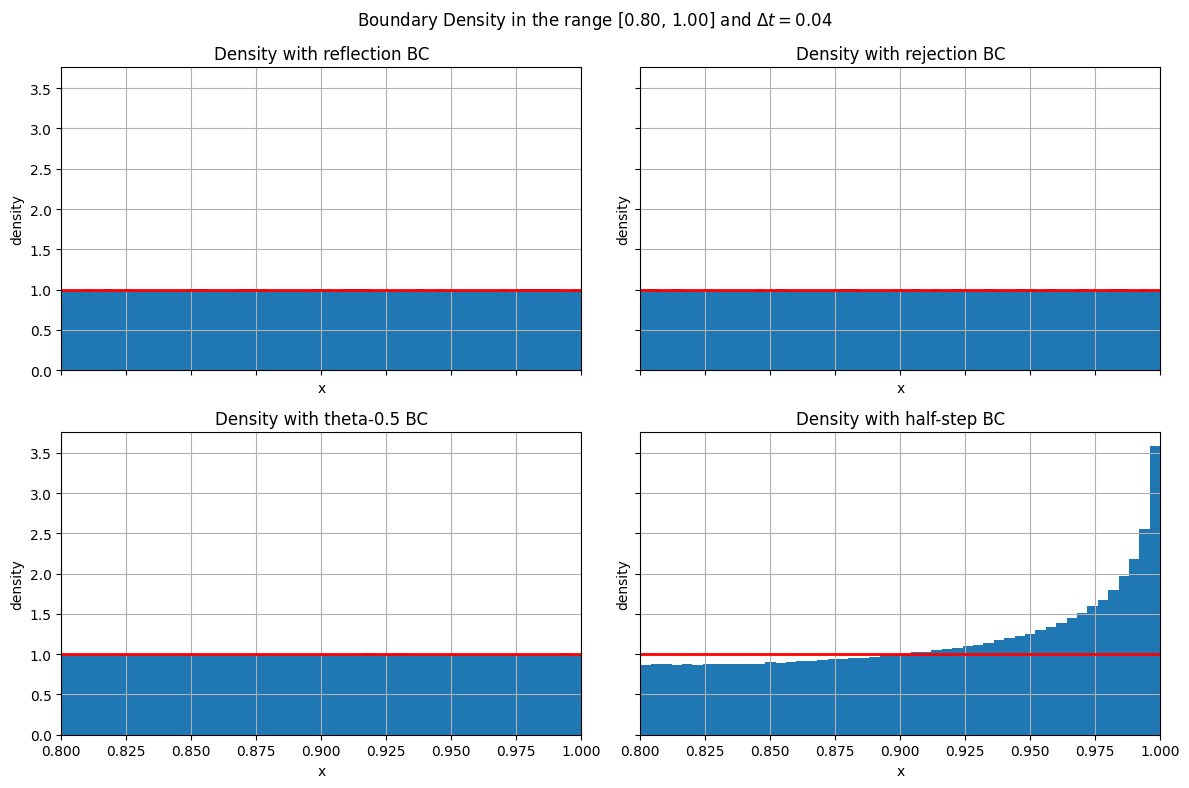

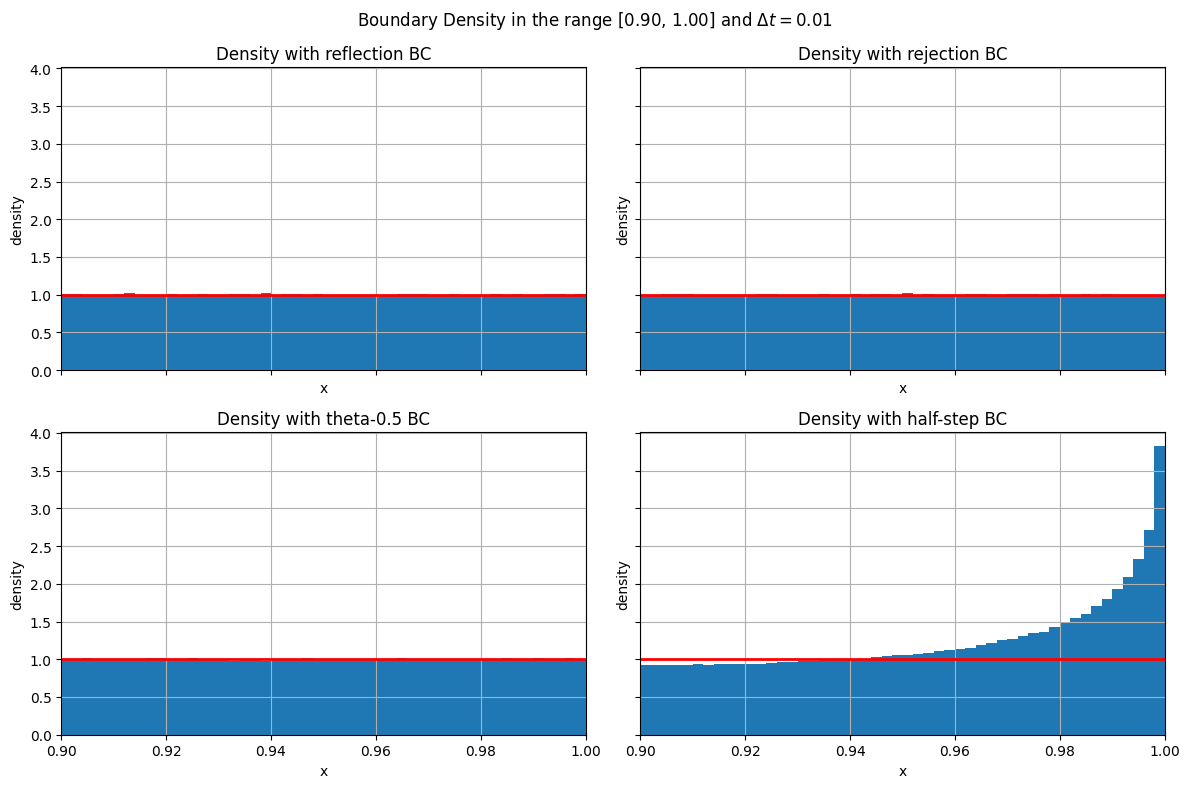

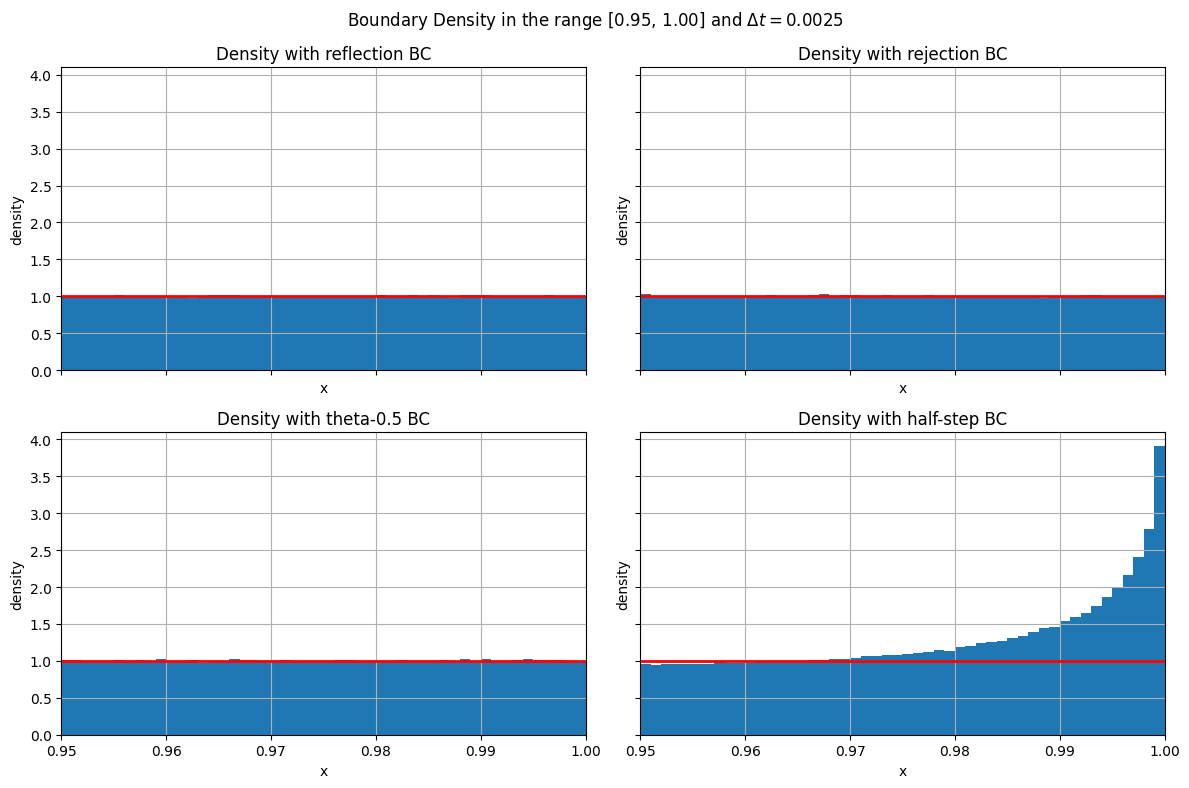

In [ ]:

bins=50

for dt in dt_list:

    epsilon = np.sqrt(dt)
    x_range = (x_bounds[1] - epsilon, x_bounds[1])

    x_plot = np.linspace(x_range[0], x_range[1], 500)
    p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    ax = ax.flatten()

    fig.suptitle(fr"Boundary Density in the range [{x_range[0]:.2f}, {x_range[1]:.2f}] with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_local_density(X=X, x_range=x_range, bins=bins, ax=ax[i]
                           , title=f'Density with {boundary_type} BC')
        ax[i].plot(x_plot, p_exact , "r", linewidth=2)

    plt.tight_layout()
    plt.show()



### Local error in the full domain

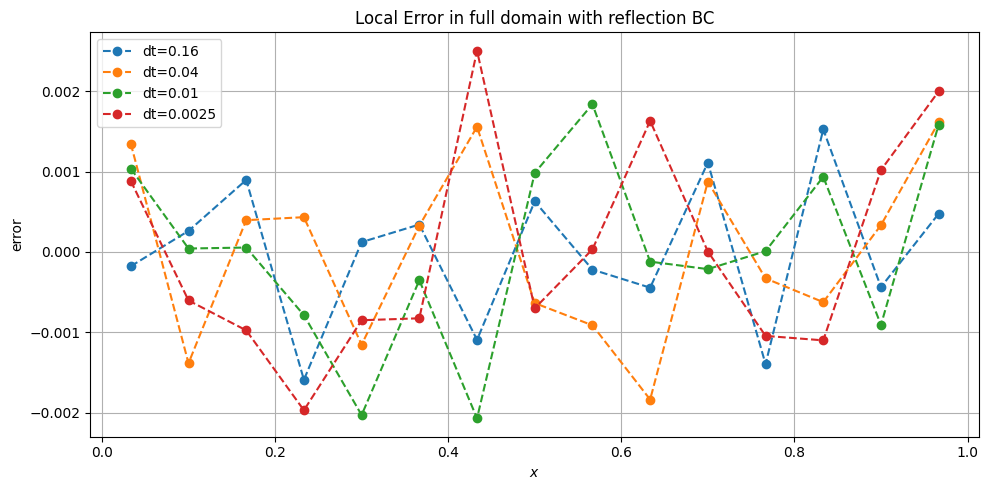

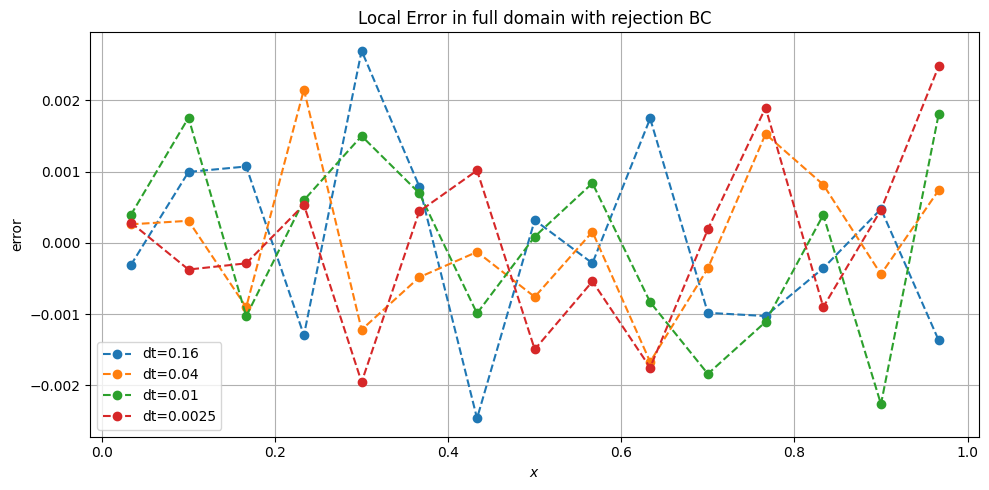

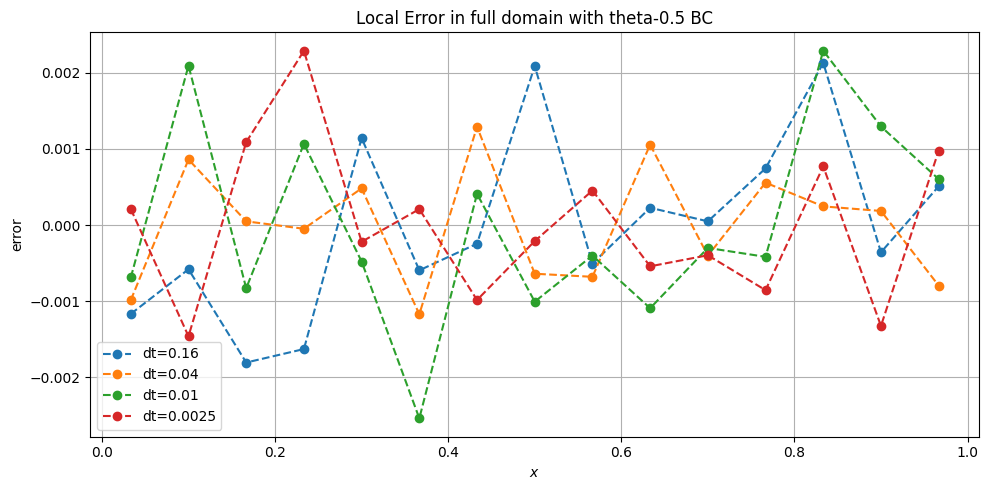

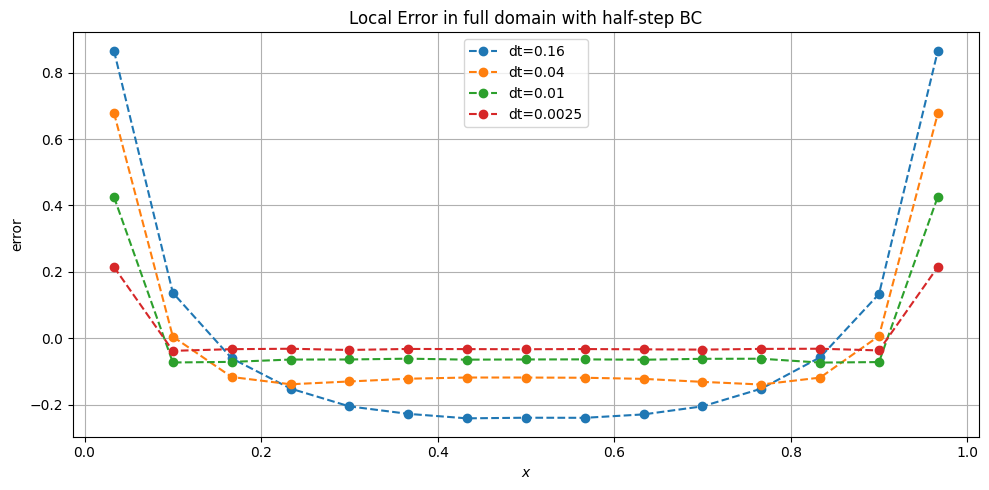

,boundary_type,dt,L1_error,L2_error,relative_error
0,reflection,0.1600,0.000715,0.000869,0.000869
1,reflection,0.0400,0.000918,0.001050,0.001050
2,reflection,0.0100,0.000865,0.001121,0.001121
3,reflection,0.0025,0.001076,0.001269,0.001269
4,rejection,0.1600,0.001079,0.001300,0.001300
5,rejection,0.0400,0.000794,0.000987,0.000987
6,rejection,0.0100,0.001075,0.001236,0.001236
7,rejection,0.0025,0.000974,0.001212,0.001212
8,theta-0.5,0.1600,0.000919,0.001140,0.001140
9,theta-0.5,0.0400,0.000630,0.000739,0.000739


In [20]:


bins=15

error_rows = []


for boundary_type in boundary_types:

    plt.figure(figsize=(10, 5))

    plt.title(f"Local Error in full domain with {boundary_type} BC")
    
    for i, dt in enumerate(dt_list):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_bounds, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)
    
        local_error, L1_error, L2_error, relative_error = density_errors(p_num, p_exact, bin_widths)
        
        plt.plot(centres, local_error, marker="o", linestyle="--", label=f"dt={dt}")
    
        error_rows.append({"boundary_type": boundary_type, "dt": dt, "L1_error": L1_error,
            "L2_error": L2_error, "relative_error": relative_error})

    plt.xlabel(r"$x$")
    plt.ylabel("error")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

error_table = pd.DataFrame(error_rows)
display(error_table)



### Convergence with diffrent BC

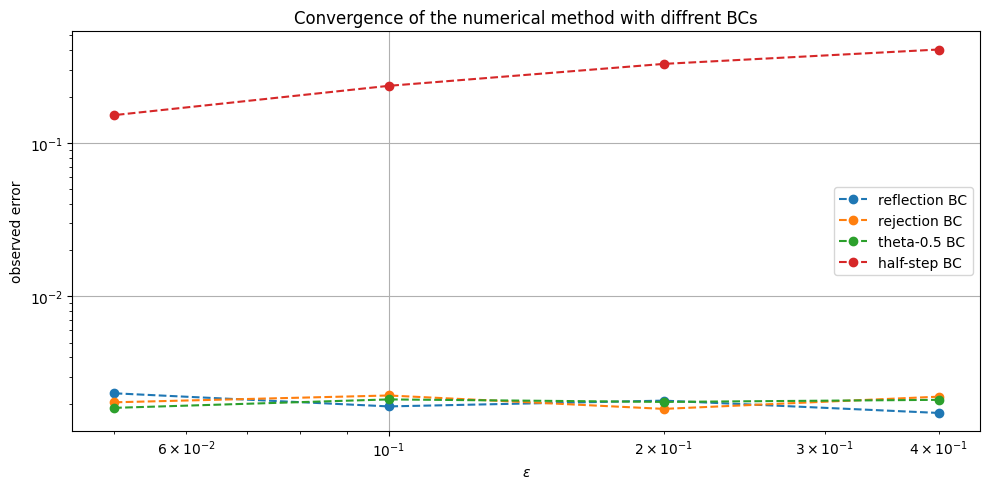

,boundary_type,observed_order
0,reflection,-0.115228
1,rejection,0.007721
2,theta-0.5,0.046846
3,half-step,0.473658


In [ ]:

bins=50

epsilon_list = [np.sqrt(dt) for dt in dt_list]

order_rows = []

plt.figure(figsize=(10, 5))
plt.title(f"Convergence of the numerical method with diffrent BCs")

for boundary_type in boundary_types:

    errors = []

    for i, dt in enumerate(dt_list):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_bounds, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)
    
        local_error, L1_error, L2_error, relative_error = density_errors(p_num, p_exact, bin_widths)
        
        errors.append(relative_error)

    epsilon_list = np.array(epsilon_list)
    errors = np.array(errors)

    plt.loglog(epsilon_list, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_list), np.log(errors), 1)[0]

    order_rows.append({"boundary_type":boundary_type, "observed_order": order})
    
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"observed error")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


convergence_table = pd.DataFrame(order_rows)
display(convergence_table)




### Local error in the scaled boundary close to $x=0$

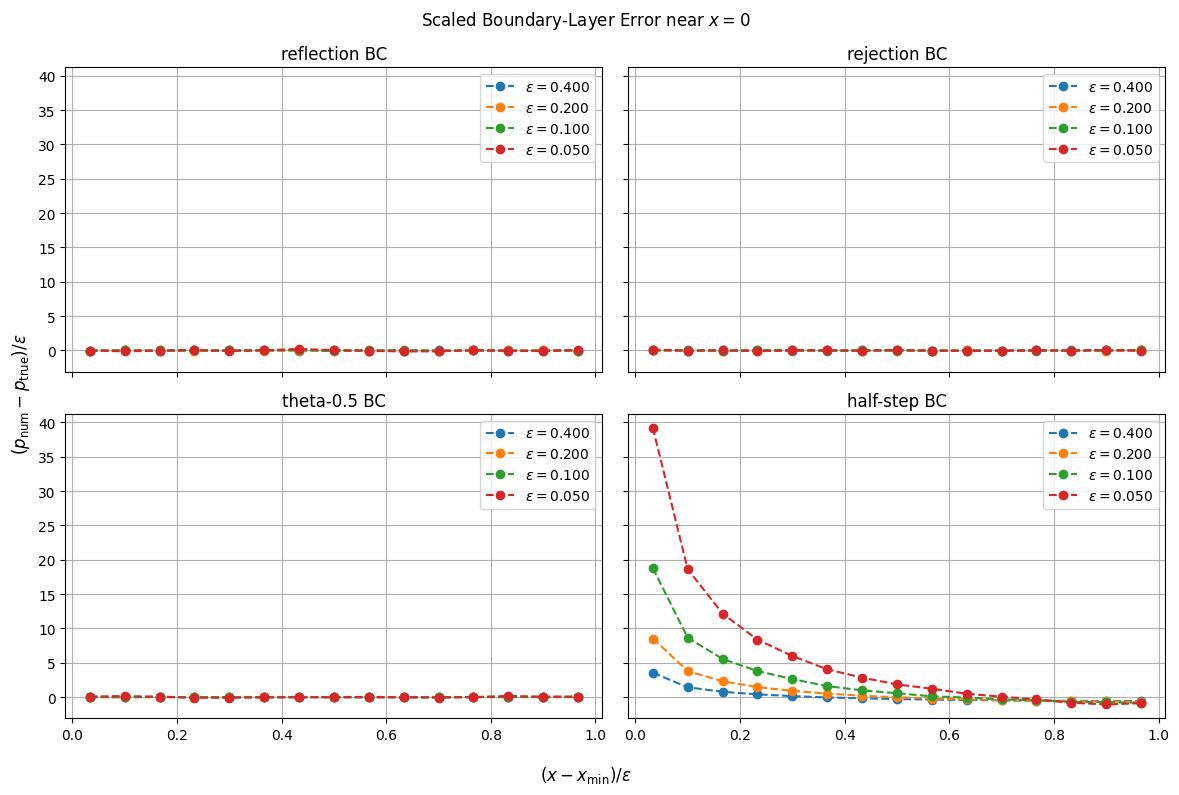

In [19]:
bins = 15

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
ax = ax.flatten()

fig.suptitle(fr"Scaled Boundary-Layer Error near $x=0$")

for i, boundary_type in enumerate(boundary_types):

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        x_range = (x_bounds[0], x_bounds[0]+ epsilon)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)

        x_scaled = (centres - x_bounds[0]) / epsilon
        error_scaled = (p_num - p_exact) / epsilon

        ax[i].plot(x_scaled, error_scaled, marker="o", linestyle="--",
                   label=fr"$\varepsilon={epsilon:.3f}$")

    ax[i].set_title(f"{boundary_type} BC")
    ax[i].grid(True)
    ax[i].legend()

fig.supxlabel(r"$(x - x_{\min})/\varepsilon$")
fig.supylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\varepsilon$")

plt.tight_layout()
plt.show()

### Local error in the scaled boundary close to $x=1$

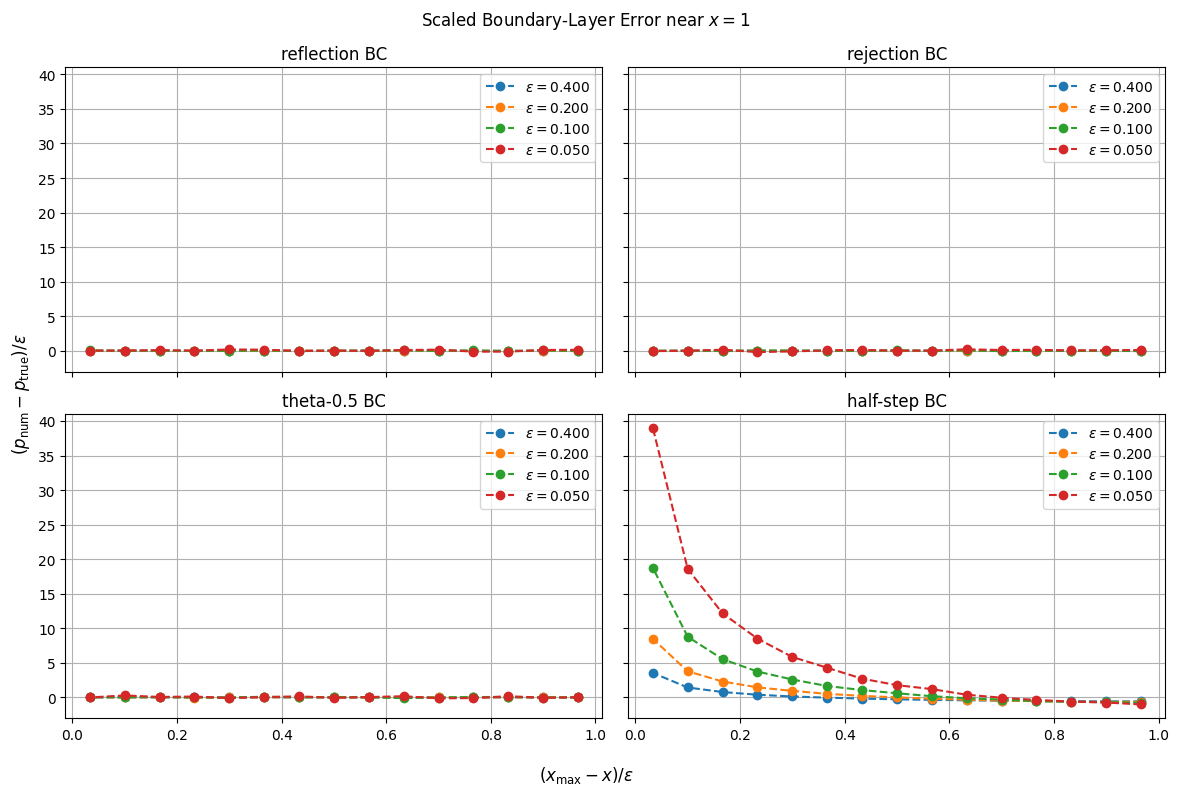

In [ ]:
bins = 15

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
ax = ax.flatten()

fig.suptitle(fr"Scaled Boundary-Layer Error near $x=1$")

for i, boundary_type in enumerate(boundary_types):

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        x_range = (x_bounds[1] - epsilon, x_bounds[1])

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)

        x_scaled = (x_bounds[1] - centres) / epsilon
        error_scaled = (p_num - p_exact) / epsilon

        ax[i].plot(x_scaled, error_scaled, marker="o", linestyle="--",
                   label=fr"$\varepsilon={epsilon:.3f}$")

    ax[i].set_title(f"{boundary_type} BC")
    ax[i].grid(True)
    ax[i].legend()

fig.supxlabel(r"$(x_{\max} - x)/\varepsilon$")
fig.supylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\varepsilon$")

plt.tight_layout()
plt.show()

### Gap in boundary layer

In [20]:
def boundary_gap(X, b, sigma, boundaries, x_range, bins=30):

    p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
    p_exact = stationary_solution(centres, b, sigma, boundaries)

    if x_range[0] == boundaries[0]:
        index = 0
    elif x_range[1] == boundaries[1]:
        index = -1

    gap = np.abs(p_num[index] - p_exact[index])

    return gap

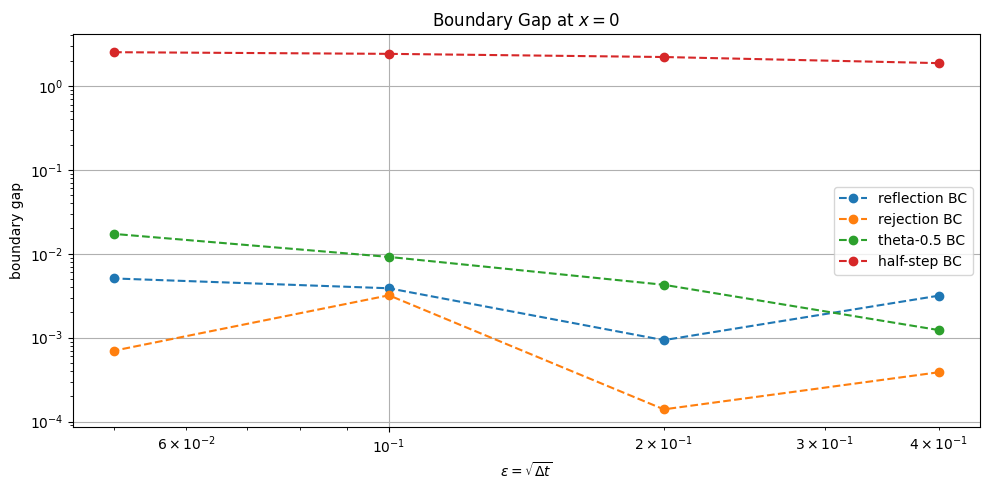

,x=,boundary_type,dt,epsilon,gap,gap_over_epsilon
0,0,reflection,0.1600,0.40,0.003168,0.007919
1,0,reflection,0.0400,0.20,0.000935,0.004675
2,0,reflection,0.0100,0.10,0.003880,0.038800
3,0,reflection,0.0025,0.05,0.005080,0.101600
4,0,rejection,0.1600,0.40,0.000387,0.000969
5,0,rejection,0.0400,0.20,0.000140,0.000700
6,0,rejection,0.0100,0.10,0.003200,0.032000
7,0,rejection,0.0025,0.05,0.000700,0.014000
8,0,theta-0.5,0.1600,0.40,0.001233,0.003081
9,0,theta-0.5,0.0400,0.20,0.004270,0.021350


In [22]:
bins = 30

gap_rows = []

plt.figure(figsize=(10, 5))

for boundary_type in boundary_types:

    gaps = []

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        x_range = (x_bounds[0], x_bounds[0]+ epsilon)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        gap = boundary_gap(X, b, sigma, x_bounds, x_range, bins=bins)
        gaps.append(gap)

        gap_rows.append({
            "x=": 0,
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": epsilon,
            "gap": gap,
            "gap_over_epsilon": gap / epsilon
        })

    plt.loglog(np.sqrt(dt_list), gaps, marker="o", linestyle="--", label=f"{boundary_type} BC")

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel("boundary gap")
plt.title(fr"Boundary Gap at $x={x_bounds[0]}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

gap_table = pd.DataFrame(gap_rows)
display(gap_table)

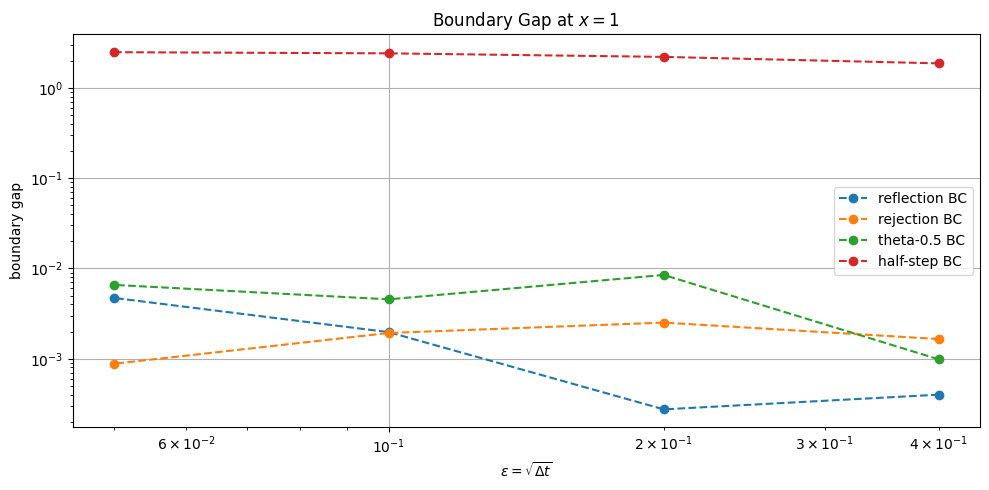

,input_boundary,boundary_type,dt,epsilon,gap,gap_over_epsilon
0,1,reflection,0.1600,0.40,0.000400,0.001000
1,1,reflection,0.0400,0.20,0.000275,0.001375
2,1,reflection,0.0100,0.10,0.001970,0.019700
3,1,reflection,0.0025,0.05,0.004720,0.094400
4,1,rejection,0.1600,0.40,0.001652,0.004131
5,1,rejection,0.0400,0.20,0.002515,0.012575
6,1,rejection,0.0100,0.10,0.001930,0.019300
7,1,rejection,0.0025,0.05,0.000880,0.017600
8,1,theta-0.5,0.1600,0.40,0.000985,0.002462
9,1,theta-0.5,0.0400,0.20,0.008480,0.042400


In [ ]:
bins = 30

gap_rows = []

plt.figure(figsize=(10, 5))

for boundary_type in boundary_types:

    gaps = []

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        x_range = (x_bounds[1] - epsilon, x_bounds[1])

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        gap = boundary_gap(X, b, sigma, x_bounds, x_range, bins=bins)
        gaps.append(gap)

        gap_rows.append({
            "x=": 1,
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": epsilon,
            "gap": gap,
            "gap_over_epsilon": gap / epsilon
        })

    plt.loglog(np.sqrt(dt_list), gaps, marker="o", linestyle="--", label=f"{boundary_type} BC")

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel("boundary gap")
plt.title(fr"Boundary Gap at $x={x_bounds[1]}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

gap_table = pd.DataFrame(gap_rows)
display(gap_table)

# =============================

## Investigate the solution near boundary, error and convergance for reflection BC

### Inspect the error close to $x=1$ (`P(X_ref) - p_true` vs `x`)

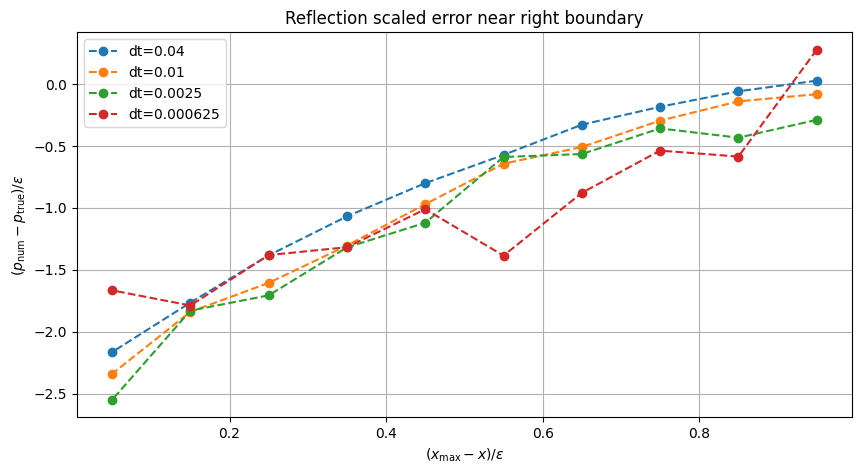

In [ ]:

bins = 10

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    epsilon = np.sqrt(dt)

    x_range = (x_bounds[1] - epsilon, x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    x_scaled = (x_bounds[1] - centres) / epsilon

    p_true = stationary_solution(centres, b, sigma, x_bounds)
    
    error_scaled = (p_num - p_true) / epsilon
    plt.plot(x_scaled, error_scaled, marker="o", linestyle="--", label=f"dt={dt}")

    


plt.title("Reflection scaled error near right boundary")
plt.xlabel(r"$(x_{\max} - x)/\epsilon$")
plt.ylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")
plt.grid(True)
plt.legend()

plt.show()

might need to remove the true (which is related to not having close form for P1 used in this caclucation)\
also, try smaller dt than the last one as it looks noisy or remove it and add a larger value than 0.04
do the same for both ends of the domain. 

### Compute global error (absolute)

dt = 0.04, global error = 0.06647
dt = 0.01, global error = 0.01969
dt = 0.0025, global error = 0.00570
dt = 0.000625, global error = 0.00184


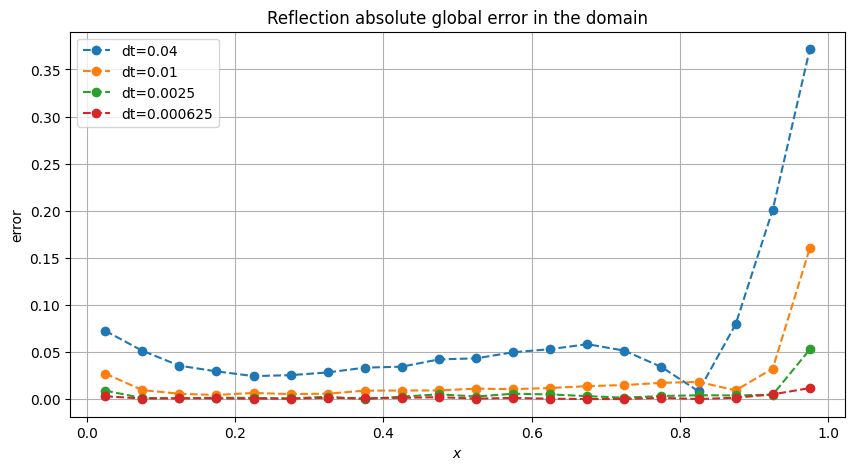

In [21]:
bins = 20

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)
    
    plt.plot(centres, np.abs(error_per_bin), marker="o", linestyle="--", label=f"dt={dt}")

    print(f"dt = {dt}, global error = {global_error:.5f}")

    


plt.title("Reflection absolute global error in the domain")
plt.xlabel(r"$x$")
plt.ylabel("error")
plt.grid(True)
plt.legend()

plt.show()

dt = 0.04, global error = 0.06647
dt = 0.01, global error = 0.01969
dt = 0.0025, global error = 0.00570
dt = 0.000625, global error = 0.00184


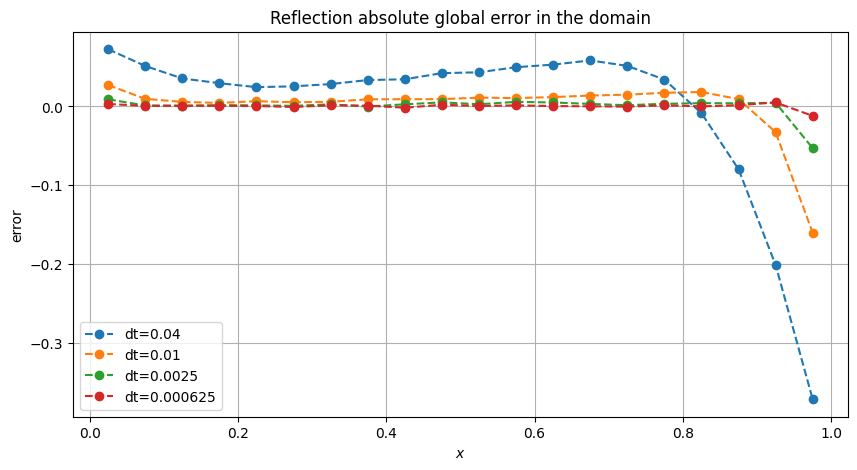

In [20]:
bins = 20

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)
    
    plt.plot(centres, error_per_bin, marker="o", linestyle="--", label=f"dt={dt}")

    print(f"dt = {dt}, global error = {global_error:.5f}")

    


plt.title("Reflection absolute global error in the domain")
plt.xlabel(r"$x$")
plt.ylabel("error")
plt.grid(True)
plt.legend()

plt.show()

### Convergence

dt = 0.04, epsilon = 0.2, global error = 0.06660
dt = 0.01, epsilon = 0.1, global error = 0.01960
dt = 0.0025, epsilon = 0.05, global error = 0.00684
dt = 0.000625, epsilon = 0.025, global error = 0.00392
estimated order of convergence = 1.378


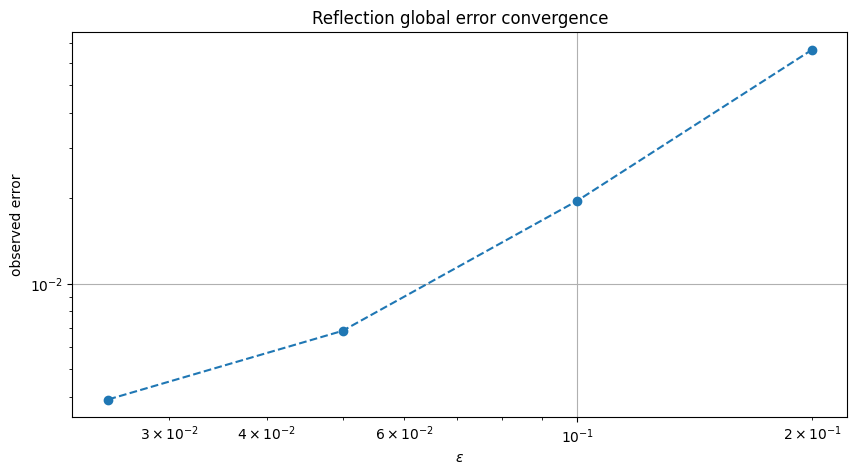

In [7]:
bins = 200

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]

epsilons = []
global_errors = []

for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])
    epsilon = np.sqrt(dt)

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)

    epsilons.append(epsilon)
    global_errors.append(global_error)

    print(f"dt = {dt}, epsilon = {epsilon}, global error = {global_error:.5f}")


print("=======")
epsilons = np.array(epsilons)
global_errors = np.array(global_errors)
order = np.polyfit(np.log(epsilons), np.log(global_errors), 1)[0]
print(f"estimated order of convergence = {order:.3f}")


plt.figure(figsize=(10, 5))

plt.loglog(epsilons, global_errors, marker="o", linestyle="--")

plt.title("Reflection global error convergence")
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"observed error")
plt.grid(True)

plt.show()

**Note:** above error is probably better be called _observed_ global error because

$error_{observed} =  error_{numerical} + error_{MonteCarlo}$

Also, it seems the number of bins has a decent impact of the error computed as well


### closer look into convergance per $\epsilon$ step


In [49]:
for i in range(len(epsilons)-1):
    error_ratio = global_errors[i] / global_errors[i+1]
    epsilon_ratio = epsilons[i] / epsilons[i+1]
    order = np.log(error_ratio) / np.log(epsilon_ratio)

    print(f"epsilon = {epsilons[i]} to {epsilons[i+1]}, error ratio = {error_ratio:.3f}, order = {order:.3f}")

epsilon = 0.2 to 0.1, error ratio = 3.418, order = 1.773
epsilon = 0.1 to 0.05, error ratio = 3.476, order = 1.797
epsilon = 0.05 to 0.025, error ratio = 2.321, order = 1.214


### small checks for later

In [57]:
bins = 50

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]

epsilons = []
global_errors = []

for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    print(f"For {dt=}:")

    x_range = (x_bounds[0], x_bounds[1])

    print(np.min(X_ref) > x_bounds[0], np.max(X_ref) < x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_bounds, bins)

    p_total = np.sum(p_num * bin_widths)

    print(p_total)

    mean_num = np.mean(X_ref)
    var_num = np.var(X_ref)

    print(f"{mean_num} and {var_num}")
    print("======")



For dt=0.04:
True True
1.0
0.6385107498722501 and 0.06990125524294907
For dt=0.01:
True True
0.9999999999999999
0.6516861844356837 and 0.06911053518905926
For dt=0.0025:
True True
1.0000000000000002
0.6551976453998409 and 0.06900001525139723
For dt=0.000625:
True True
0.9999999999999999
0.6561863224911985 and 0.06903161589649348


## To do next

In [ ]:
### I used this code to compute the theoratical error in boundary side. but it may have been worng
#   all along. I will keep it and give it another try once I implement linear diffusion


# # p at the boundary
# p_0_xmax = stationary_solution(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

# sigma_prime = 0 #this is for the case of constant diffusion

# X_plot = np.linspace(0, 1 , 200)

# # this is similar to P^(1) as X goes to inf
# P_1 = 2 *(b(0,0)/sigma(0,0)**2) * X_plot * p_0_xmax

# p_true_prime_xmax = stationary_solution_prime(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

# #this quantitiy is 0 for this problem, need more complicated problem to see diffrent curve
# error_true = P_1 - X_plot* p_true_prime_xmax 


# plt.plot(X_plot, error_true, linestyle="-", label=r"true error")
